In [11]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

data = pd.read_csv("xy_data.csv")
xs, ys = data.iloc[:,0].values, data.iloc[:,1].values

def residuals(params):
    theta_deg, M, X = params
    theta = np.radians(theta_deg)

    u = (xs - X) * np.cos(theta) + (ys - 42) * np.sin(theta)
    v = -(xs - X) * np.sin(theta) + (ys - 42) * np.cos(theta)

    predicted_v = np.exp(M * np.abs(u)) * np.sin(0.3 * u)
    return v - predicted_v

res = least_squares(
    residuals,
    x0=[25, 0.0, 50],
    bounds=([0, -0.05, 0], [50, 0.05, 100]),
    xtol=1e-15, ftol=1e-15, gtol=1e-15
)

theta_deg, M, X = res.x
print("theta (deg):", theta_deg)
print("theta (rad):", np.radians(theta_deg))
print("M:", M)
print("X:", X)
print("residual norm:", np.sum(res.fun**2))

theta (deg): 29.999972932158293
theta (rad): 0.5235983031753396
M: 0.029999996873059678
X: 54.99999821279947
residual norm: 1.822997935931109e-08


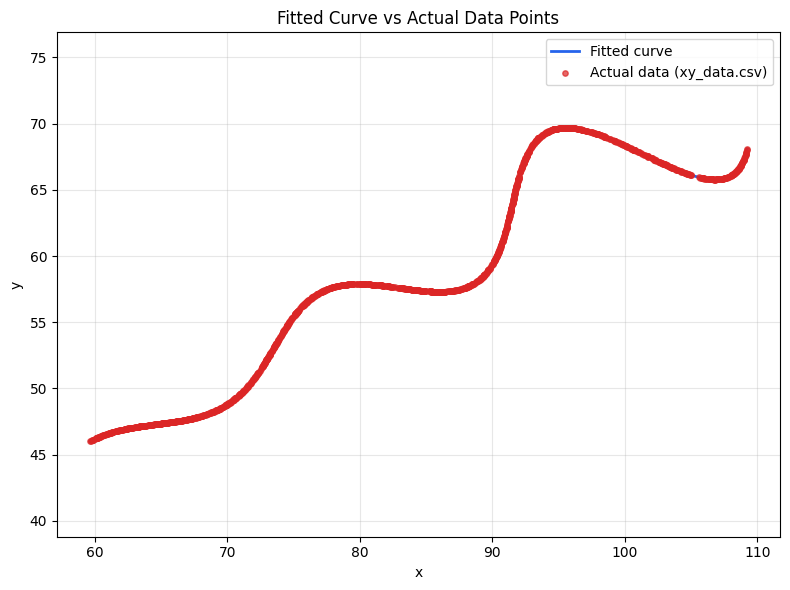

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("xy_data.csv")
xs_actual = data["x"].values
ys_actual = data["y"].values

theta_deg = 29.999972932158293
theta = np.radians(theta_deg)
M = 0.029999996873059678
X = 54.99999821279947

t = np.linspace(6, 60, 2000)
inner = np.exp(M * np.abs(t)) * np.sin(0.3 * t)
x_curve = t * np.cos(theta) - inner * np.sin(theta) + X
y_curve = 42 + t * np.sin(theta) + inner * np.cos(theta)

plt.figure(figsize=(8, 6))
plt.plot(x_curve, y_curve, color="#2563eb", linewidth=2, label="Fitted curve", zorder=2)
plt.scatter(xs_actual, ys_actual, color="#dc2626", s=15, alpha=0.7, label="Actual data (xy_data.csv)", zorder=3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted Curve vs Actual Data Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.savefig("fitted_curve_vs_data.png", dpi=150)
plt.show()

In [17]:
import numpy as np
import pandas as pd

data = pd.read_csv("xy_data.csv")
print("Columns found:", data.columns.tolist())
print(data.head())

xs_actual = data.iloc[:, 0].values
ys_actual = data.iloc[:, 1].values
n = len(xs_actual)

theta_deg = 29.999972932158293
theta = np.radians(theta_deg)
M = 0.029999996873059678
X = 54.99999821279947


t_fine = np.linspace(6, 60, 5000)
inner_fine = np.exp(M * np.abs(t_fine)) * np.sin(0.3 * t_fine)
x_curve = t_fine * np.cos(theta) - inner_fine * np.sin(theta) + X
y_curve = 42 + t_fine * np.sin(theta) + inner_fine * np.cos(theta)

dx = np.abs(xs_actual[:, None] - x_curve[None, :])
dy = np.abs(ys_actual[:, None] - y_curve[None, :])
l1_matrix = dx + dy
l1_nearest = l1_matrix.min(axis=1)

print("Total L1 distance:", l1_nearest.sum())
print("Mean L1 distance:", l1_nearest.mean())
print("Max L1 distance:", l1_nearest.max())

Columns found: ['x', 'y']
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
Total L1 distance: 6.110854025035252
Mean L1 distance: 0.0040739026833568346
Max L1 distance: 0.012356423917140091
